# MACHINE LEARNING

## Predictive Machine Failure Classification

### Business Problem

Manufacturing companies lose significant time and money due to unexpected machine failures. The objective of this analysis is to build a machine learning model that predicts whether a machine is likely to fail within the next 7 days using historical sensor readings. Accurate predictions enable maintenance teams to perform preventive maintenance, reduce downtime, lower maintenance costs, and improve overall production efficiency.


In [6]:
# Import Required Libraries 
import pandas as pd 
import numpy as np 

from sklearn.model_selection import train_test_split 

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt 
import seaborn as sns 


In [7]:
sensor_data = pd.read_csv("../📁Data/📁Cleaned_Data/Sensor Readings.csv")

sensor_data.head()

,sensor_reading_id,machine_id,line_id,factory_id,reading_timestamp,temperature_c,vibration_mm_s,pressure_bar,oil_level_percent,voltage_v,current_amp,rpm,sound_level_db,machine_health_score,alert_status,failure_within_7_days,linked_failure_event_id
0,SNS0000001,MCH0212,LIN030,FAC010,2025-01-28 19:38:45,33.25,3.692,5.33,76.90,412.77,33.29,878.2,71.68,82,Normal,0,NaN
1,SNS0000002,MCH0134,LIN006,FAC002,2026-05-05 18:25:04,60.37,3.179,5.04,85.60,413.53,38.28,1437.8,75.88,93,Normal,0,NaN
2,SNS0000003,MCH0227,LIN023,FAC008,2024-12-23 19:29:20,70.58,0.888,5.12,71.21,429.69,27.93,1762.9,69.30,97,Normal,0,NaN
3,SNS0000004,MCH0059,LIN012,FAC004,2023-05-17 02:02:47,42.87,2.900,3.83,63.01,430.38,28.13,746.3,69.73,88,Normal,0,NaN
4,SNS0000005,MCH0474,LIN003,FAC001,2025-08-10 14:59:02,60.29,4.685,6.27,73.69,409.80,44.78,1212.4,63.75,83,Normal,0,NaN


In [8]:
sensor_data.columns 

Index(['sensor_reading_id', 'machine_id', 'line_id', 'factory_id',
       'reading_timestamp', 'temperature_c', 'vibration_mm_s', 'pressure_bar',
       'oil_level_percent', 'voltage_v', 'current_amp', 'rpm',
       'sound_level_db', 'machine_health_score', 'alert_status',
       'failure_within_7_days', 'linked_failure_event_id'],
      dtype='str')

In [9]:
sensor_data.shape

(285000, 17)

In [10]:
sensor_data.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_c,283800.0,101.207083,103.468380,15.510,51.320,63.930,74.090,450.580
vibration_mm_s,284656.0,3.232278,1.713325,0.001,2.412,3.154,3.888,59.718
pressure_bar,285000.0,6.032738,0.729835,2.660,5.540,6.020,6.500,9.870
oil_level_percent,285000.0,70.056473,8.008465,20.030,65.190,70.300,75.360,100.000
voltage_v,285000.0,415.658313,16.109991,366.030,408.480,415.270,422.150,1096.810
current_amp,285000.0,41.913550,6.668273,13.500,37.460,41.750,46.110,86.040
rpm,285000.0,1366.301013,686.230798,0.000,1003.000,1585.200,1902.300,2823.600
sound_level_db,285000.0,72.487482,4.482051,53.520,69.520,72.350,75.240,101.020
machine_health_score,285000.0,84.630579,8.535166,5.000,80.000,85.000,91.000,98.000
failure_within_7_days,285000.0,0.027070,0.162288,0.000,0.000,0.000,0.000,1.000


In [11]:
sensor_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 285000 entries, 0 to 284999
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   sensor_reading_id        285000 non-null  str    
 1   machine_id               285000 non-null  str    
 2   line_id                  285000 non-null  str    
 3   factory_id               285000 non-null  str    
 4   reading_timestamp        285000 non-null  str    
 5   temperature_c            283800 non-null  float64
 6   vibration_mm_s           284656 non-null  float64
 7   pressure_bar             285000 non-null  float64
 8   oil_level_percent        285000 non-null  float64
 9   voltage_v                285000 non-null  float64
 10  current_amp              285000 non-null  float64
 11  rpm                      285000 non-null  float64
 12  sound_level_db           285000 non-null  float64
 13  machine_health_score     285000 non-null  int64  
 14  alert_status   

In [12]:
sensor_data.duplicated().sum()

np.int64(0)

In [13]:
sensor_data["failure_within_7_days"].value_counts()

failure_within_7_days
0    277285
1      7715
Name: count, dtype: int64

In [14]:
sensor_data["failure_within_7_days"].value_counts(normalize=True) * 100

failure_within_7_days
0    97.292982
1     2.707018
Name: proportion, dtype: float64

C:\Users\gunnu\AppData\Local\Temp\ipykernel_20512\1202882449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


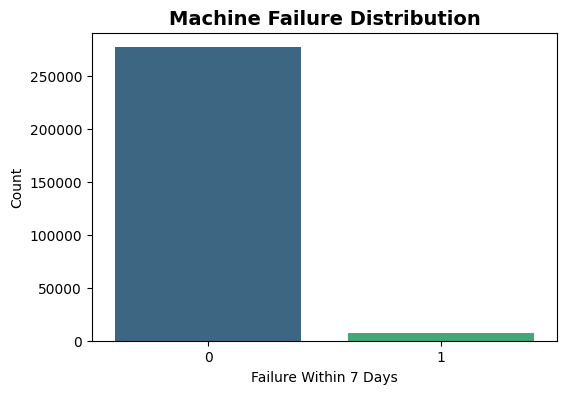

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=sensor_data,
    x="failure_within_7_days",
    palette="viridis"
)

plt.title(
    "Machine Failure Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Failure Within 7 Days")
plt.ylabel("Count")

plt.show()

In [16]:
ml_data = sensor_data.dropna(
    subset=[
        "temperature_c",
        "vibration_mm_s"
    ]
)

print("Original Shape:", sensor_data.shape)
print("New Shape:", ml_data.shape)

Original Shape: (285000, 17)
New Shape: (283457, 17)


In [17]:
features = [
    "temperature_c",
    "vibration_mm_s",
    "pressure_bar",
    "oil_level_percent",
    "voltage_v",
    "current_amp",
    "rpm",
    "sound_level_db",
    "machine_health_score"
]

target = "failure_within_7_days"

In [18]:
X = ml_data[features]
y = ml_data[target]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (283457, 9)
y Shape: (283457,)


In [19]:
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (226765, 9)
Testing Set  : (56692, 9)


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
X_train_scaled

array([[-0.35979952,  0.20747275,  1.09440286, ...,  0.50329568,
        -0.52966859,  0.39677492],
       [ 2.71437862, -0.8010392 , -1.45577521, ..., -1.99794171,
         0.4181596 , -0.18880549],
       [-0.306086  ,  0.58824348, -0.12584363, ...,  0.81720965,
         0.31111077, -0.65726982],
       ...,
       [-0.26662498,  0.48037808, -1.15414124, ...,  1.10805461,
        -0.34010295, -1.24285023],
       [-0.50814192, -0.535207  ,  0.64195192, ...,  0.17405101,
         0.6969326 ,  0.27965883],
       [-0.52918133,  0.24460673,  1.16295604, ...,  0.47102824,
         0.4872953 ,  0.63100708]], shape=(226765, 9))

### OUR TARGET IS TO FIGURE OUT :
#### THE FAILURE OF MACHINE IN 7 DAYS 
#### 0 = No Failure 
#### 1 = Failure 
### This is a Binary Classification Problem.


In [22]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [23]:
y_pred = logistic_model.predict(X_test_scaled)

y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print(y_pred)
print(y_prob)

[1 0 0 ... 0 0 0]
[9.99819454e-01 1.08790985e-02 2.21580659e-03 ... 1.89089437e-02
 1.11824338e-03 2.78171494e-05]


In [24]:
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy  : 0.9913
Precision : 0.9571
Recall    : 0.7113
F1 Score  : 0.8161
ROC AUC   : 0.9686


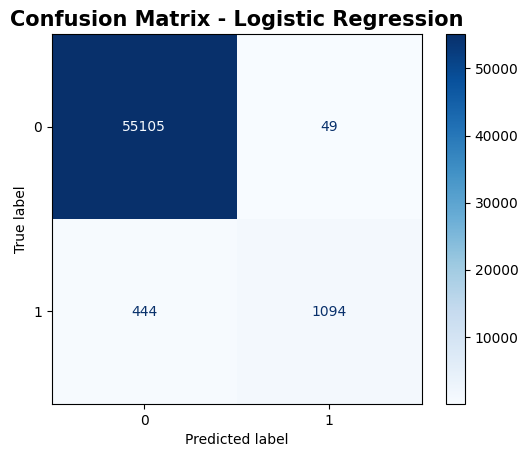

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title(
    "Confusion Matrix - Logistic Regression",
    fontsize=15,
    fontweight="bold"
)

plt.show()

## Business Problem

### Build a Decision Tree model to predict whether a machine is likely to fail within the next 7 days using sensor readings and compare its performance with Logistic Regression.

In [26]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [27]:
y_pred_dt = decision_tree.predict(X_test)

y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]


In [28]:
print(f"Accuracy  : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_dt):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob_dt):.4f}")

Accuracy  : 0.9879
Precision : 0.7800
Recall    : 0.7724
F1 Score  : 0.7762
ROC AUC   : 0.8832


In [29]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     55154
           1       0.78      0.77      0.78      1538

    accuracy                           0.99     56692
   macro avg       0.89      0.88      0.89     56692
weighted avg       0.99      0.99      0.99     56692



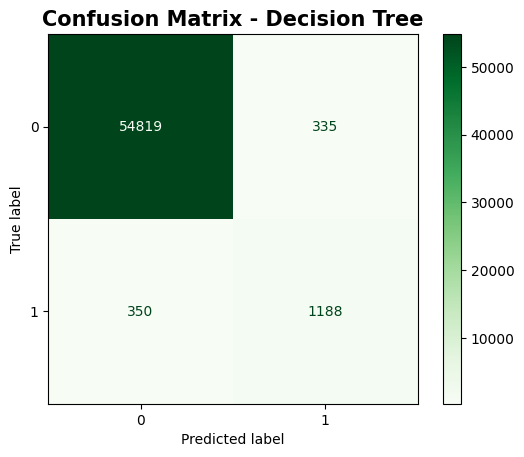

In [30]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    cmap="Greens"
)

plt.title(
    "Confusion Matrix - Decision Tree",
    fontsize=15,
    fontweight="bold"
)

plt.show()

In [31]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
)

random_forest.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [32]:
y_pred_rf = random_forest.predict(X_test)

y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [33]:
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob_rf):.4f}")

Accuracy  : 0.9932
Precision : 0.9793
Recall    : 0.7672
F1 Score  : 0.8604
ROC AUC   : 0.9668


In [34]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     55154
           1       0.98      0.77      0.86      1538

    accuracy                           0.99     56692
   macro avg       0.99      0.88      0.93     56692
weighted avg       0.99      0.99      0.99     56692



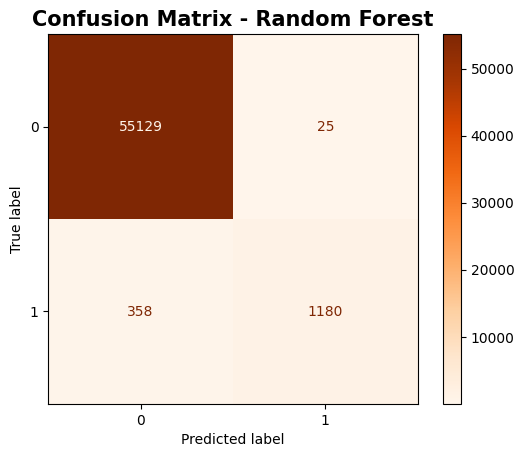

In [35]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Oranges"
)

plt.title(
    "Confusion Matrix - Random Forest",
    fontsize=15,
    fontweight="bold"
)

plt.show()

In [36]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.9913,
        0.9879,
        0.9932
    ],
    "Precision": [
        0.9571,
        0.7800,
        0.9793
    ],
    "Recall": [
        0.7113,
        0.7724,
        0.7672
    ],
    "F1 Score": [
        0.8161,
        0.7762,
        0.8604
    ],
    "ROC AUC": [
        0.9686,
        0.8832,
        0.9668
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9913,0.9571,0.7113,0.8161,0.9686
1,Decision Tree,0.9879,0.7800,0.7724,0.7762,0.8832
2,Random Forest,0.9932,0.9793,0.7672,0.8604,0.9668


## Final Model Selection

Three classification models were evaluated to predict machine failures using sensor readings.

- Logistic Regression provided excellent precision and strong overall discrimination but detected fewer machine failures.
- Decision Tree achieved the highest recall but produced more false positive predictions and lower overall performance.
- Random Forest achieved the best balance across all evaluation metrics, including the highest accuracy, precision, and F1-score while maintaining excellent ROC-AUC.

Based on these results, the Random Forest model is recommended for deployment as an early warning system for predictive maintenance. It can help maintenance teams identify high-risk machines, reduce unexpected equipment failures, minimize production downtime, and optimize maintenance scheduling.

In [37]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,vibration_mm_s,0.373217
3,oil_level_percent,0.142738
8,machine_health_score,0.142325
7,sound_level_db,0.108748
5,current_amp,0.073017
2,pressure_bar,0.054146
0,temperature_c,0.043496
4,voltage_v,0.036779
6,rpm,0.025535


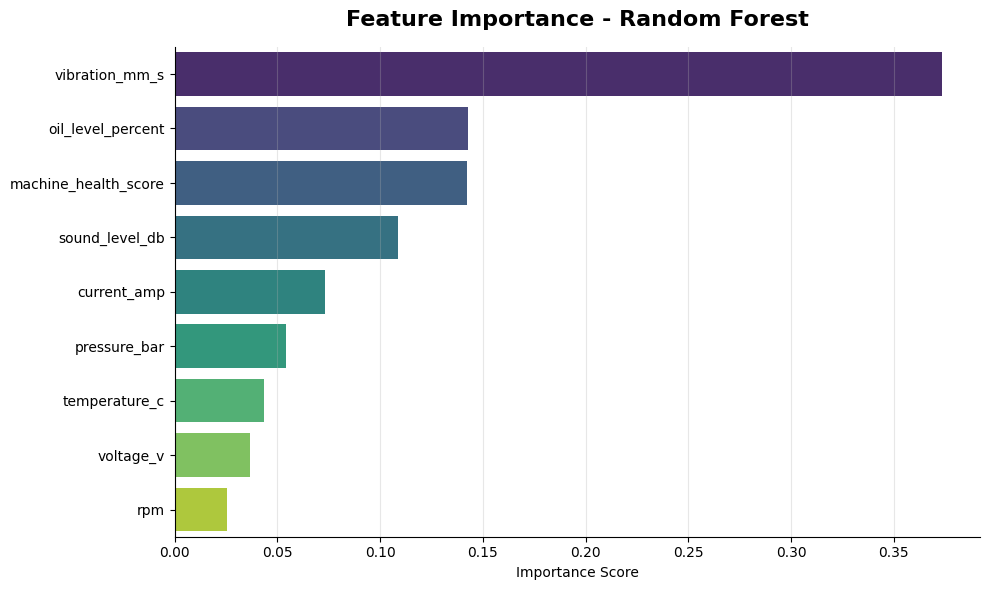

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    y="Feature",
    x="Importance",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title(
    "Feature Importance - Random Forest",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Importance Score")
plt.ylabel("")

plt.grid(axis="x", alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

### Business Insight

The Random Forest model identified **vibration**, **oil level**, and **machine health score** as the three most influential features for predicting machine failures. Together, these variables contributed the largest share of the model's decision-making process, indicating that mechanical condition and lubrication are the strongest indicators of impending equipment failure.

Features such as **sound level** and **current consumption** also played a meaningful role, while **temperature**, **voltage**, and **RPM** had comparatively lower importance in this dataset.

---

### Business Recommendation

Maintenance teams should prioritize continuous monitoring of **vibration**, **oil level**, and **machine health score**, as these are the strongest predictors of machine failure. Implementing automated alerts for abnormal changes in these sensor readings can enable earlier maintenance interventions, reduce unexpected breakdowns, and improve equipment reliability.

Although temperature, voltage, and RPM were less influential in this model, they should continue to be monitored as part of a comprehensive predictive maintenance strategy.


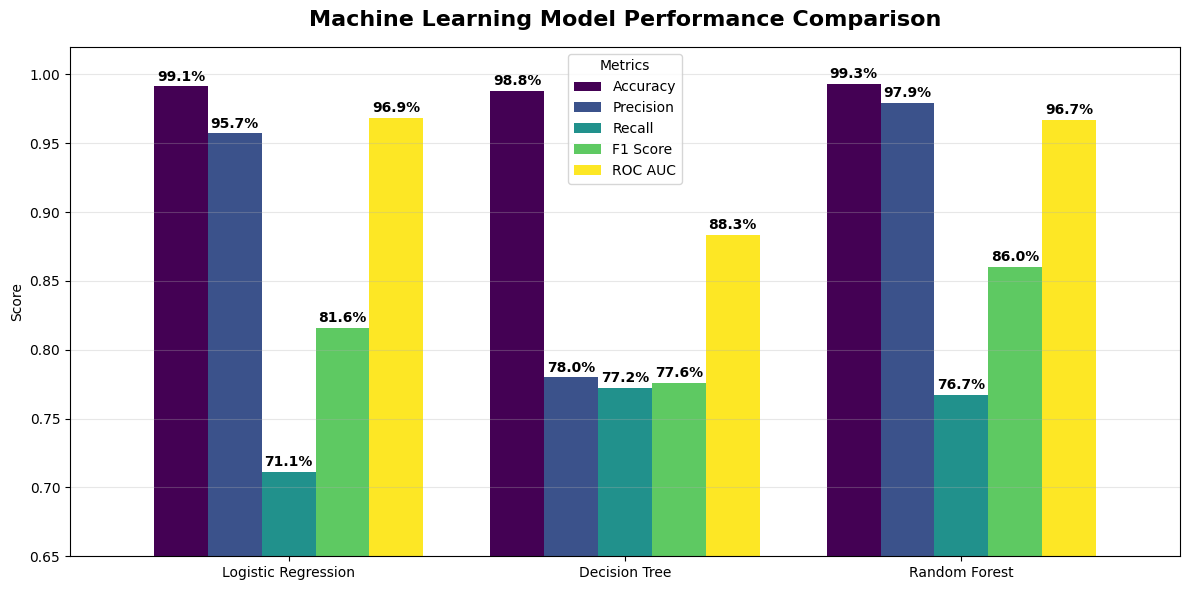

In [39]:
comparison_plot = comparison.set_index("Model")

ax = comparison_plot.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8,
    colormap="viridis"
)

plt.title(
    "Machine Learning Model Performance Comparison",
    fontsize=16,
    fontweight="bold",
    pad=15
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        labels=[f"{v*100:.1f}%" for v in container.datavalues],
        fontsize=10,
        padding=2,
        fontweight="bold"
    )

plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0.65, 1.02)

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.legend(title="Metrics")

plt.tight_layout()

plt.show()

## Business Insight

Three machine learning models were evaluated to predict machine failures using manufacturing sensor data.

- **Logistic Regression** achieved excellent Precision (95.7%) and ROC-AUC (96.9%), making it a strong and interpretable baseline model.
- **Decision Tree** achieved the highest Recall (77.2%), identifying more actual machine failures, but generated more false positive predictions.
- **Random Forest** delivered the strongest overall performance, achieving the highest Accuracy (99.3%), Precision (97.9%), and F1-Score (86.0%) while maintaining an excellent ROC-AUC (96.7%).

Overall, the Random Forest classifier provides the best balance between accurately detecting machine failures and minimizing unnecessary maintenance actions.

## Business Recommendation

Based on the model evaluation, the **Random Forest classifier** is recommended for predictive maintenance applications.

The model can be integrated into manufacturing monitoring systems to continuously analyze machine sensor readings and identify equipment at high risk of failure before breakdowns occur.

The feature importance analysis highlighted **vibration**, **oil level**, and **machine health score** as the most influential predictors of machine failure. Maintenance teams should prioritize these sensor readings by implementing real-time monitoring and automated alerts.

Deploying this predictive maintenance solution can help organizations:

- Reduce unexpected machine failures
- Minimize production downtime
- Improve equipment reliability
- Optimize preventive maintenance schedules
- Lower maintenance and operational costs


In [40]:
import joblib

joblib.dump(random_forest, "../Models/random_forest.pkl")

['../Models/random_forest.pkl']

In [41]:
joblib.dump(scaler, "../Models/scaler.pkl")


['../Models/scaler.pkl']

In [45]:
import joblib

model = joblib.load("../Models/random_forest.pkl")

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
